# Pandas Visualization

In [3]:
# %pip install pandas numpy     ### ensure pandas and numpy are installed; uncomment when done
# %pip install matplotlib       ### ensure matplotlib is installed; uncomment when done

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt ### because pandas.plot is still matplotlib
# %matplotlib inline            ### uncomment if using Jupyter Notebook
                                ### unless using Jupyter < 7
                                ### use plt.show() to display plots in other environments  

<!-- # Sample DataFrames for demonstration
import numpy as np

# Create sample data for examples
np.random.seed(42)

df1 = pd.DataFrame({
    'A': np.random.randn(100),
    'B': np.random.randn(100),
    'C': np.random.randn(100)
})

# Use positive values to support stacked area plots
df2 = pd.DataFrame({
    'a': np.random.rand(50),
    'b': np.random.rand(50),
    'c': np.random.rand(50)
}) -->

## Overview

Pandas offers a simple, high-level interface for creating plots directly from Series and DataFrame objects. It builds on Matplotlib behind the scenes, allowing you to make quick, readable plots with calls like `df.plot()` or `series.plot()`. You can easily produce line, bar/stacked bar, area, scatter, box, histogram, KDE, hexbin, and pie charts while using your **index** (including datetime) and **column labels**. 

### The `.plot()` Method

`.plot()`, a wrapper around Matplotlib's `plt.plot()`, is the primary top-level plotting method in pandas, which uses the `kind` **keyword argument** to access a variety of plotting methods including:

- `bar` or `barh` for bar plots
- `hist` for histogram
- `box` for boxplot
- `kde’ or `density` for density plots
- `area` for area plots
- `scatter` for scatter plots
- `hexbin` for hexagonal bin plots
- `pie` for pie plots

### The Plotting Methods (**`df.plot.<kind>`**)

Instead of the `kind=` arguments, your can use the plotting methods directly by using the **`df.plot.<kind>`** syntax, which makes it easier to find other plot methods. In the Python shell, you hit the tab key after df.plot., and in Jupyter, you just type til the dot and the menu with the methods will show up.

```bash
(.venv) tcn85✪mstː~/workspace/dsm$ python
Python 3.13.7 (main, Aug 14 2025, 11:12:11) [Clang 17.0.0 (clang-1700.0.13.3)] on darwin
Type "help", "copyright", "credits" or "license" for more information.
```
```python
>>> import pandas as pd
>>> df = pd.DataFrame()
>>> df.plot.<TAB>
df.plot.area(     df.plot.box(      df.plot.hist(     df.plot.pie(      
df.plot.bar(      df.plot.density(  df.plot.kde(      df.plot.scatter(  
df.plot.barh(     df.plot.hexbin(   df.plot.line(  
```

### Sample Plots

For example, here we have a piece of randomly generated time series data to plot using `.plot()`, which by default gives you a **line plot**. Because the index consists of dates, `.plot()` calls `gcf().autofmt_xdate()` to try to format the x-axis. 

Text(0.5, 1.0, 'Random Walk Simulation')

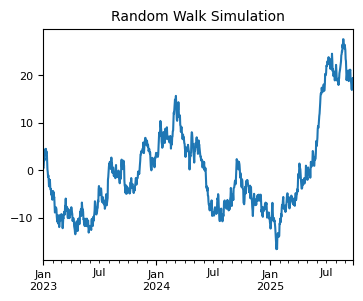

In [4]:
np.random.seed(42)  ### for reproducibility
n = 1000            ### number of time points
ts = pd.Series(np.random.randn(n), index=pd.date_range("2023-01-01", periods=n))
ts = ts.cumsum()    ### cumulative sum to create a random walk

ax = ts.plot(figsize=(4, 3), fontsize=8)  ### plot the entire time series
ax.set_title("Random Walk Simulation", fontsize=10)

For DataFrames, `.plot()` plots all of the columns with labels.

<Figure size 640x480 with 0 Axes>

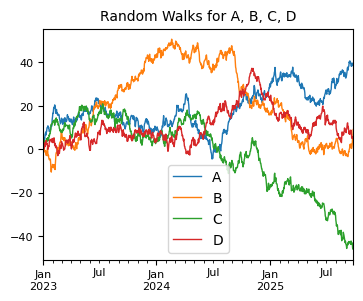

In [5]:
df = pd.DataFrame(np.random.randn(1000, 4), index=ts.index, columns=list("ABCD"))
df = df.cumsum()
plt.figure();
df.plot(figsize=(4, 3), lw=1, fontsize=8);  ### plot all columns together
plt.title("Random Walks for A, B, C, D", fontsize=10);

Or you can pick columns of your choice to plot.

          B         C  A
0 -0.423760 -0.453414  0
1 -2.219403 -0.783504  1
2 -1.486574 -2.057736  2


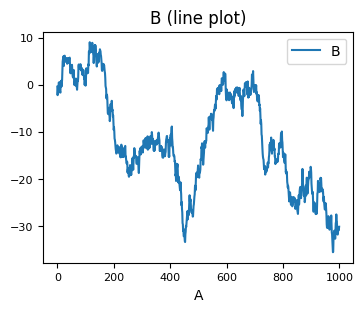

In [6]:
df1 = pd.DataFrame(np.random.randn(1000, 2), columns=["B", "C"]).cumsum()
df1["A"] = pd.Series(list(range(len(df1))))
print(df1.head(3))
df1.plot(x="A", y="B", figsize=(4, 3), fontsize=8, title="B (line plot)");

A histogram can be create with `pd.plot(kind="hist")`. Here we use the **`kind=`** keyword argument to specify the type of plot.

                   A         B         C         D
2023-01-01  1.399355  0.924634  0.059630 -0.646937
2023-01-02  2.097579  1.318119  0.954824 -0.011765
2023-01-03  3.147131  0.782884  2.272218  0.185835
2023-01-04  5.222392  0.093696  4.008181  0.383745
2023-01-05  4.570974 -0.390190  3.687834  0.807911


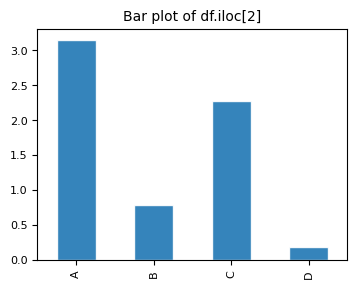

In [7]:
print(df.head())
# plt.figure();
df.iloc[2].plot(kind="bar", figsize=(4, 3), 
        title="Bar plot of df.iloc[2] (using 'kind' argument)", 
        edgecolor="white",
        alpha=0.9,
        fontsize=8);
plt.title("Bar plot of df.iloc[2]", fontsize=10);

We can use the `.plot(kind=)` syntax to generate plots other than the default line plot. For example, a histogram. 

<Axes: title={'center': 'Histogram of ts'}, ylabel='Frequency'>

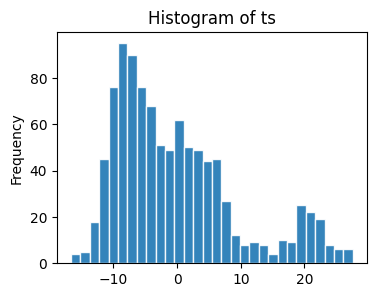

In [8]:
ts.plot(kind="hist", bins=30, figsize=(4, 3),
        title="Histogram of ts",
        edgecolor="white",
        alpha=0.9)

The same plot can be produced using the **`plot.hist()`** method. 

<Axes: title={'center': 'Histogram of ts (using method)'}, ylabel='Frequency'>

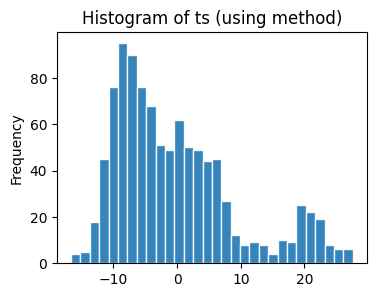

In [9]:
ts.plot.hist(bins=30, figsize=(4, 3),
             title="Histogram of ts (using method)",
             edgecolor="white",
             alpha=0.9)

For example, for histograms:
    1. `df.plot.hist()`: Uses Pandas’ unified `.plot()` interface (which wraps Matplotlib) to draw a histogram.
    2. `df.plot(kind='hist')`: The same as df.plot.hist(); a generic form of the same call.
    3. Pandas has two top-level plotting methods: `df.hist()` (a quick wrapper around Matplotlib’s `plt.hist()` for all numeric columns) and `df.boxplot()`.



| # | Method                 | Applies to          | Subplots              | Overlays Multiple Columns | Based On                 | Typical Use                           |
|:-:|:---------------------- |:------------------- |:--------------------- |:------------------------- |:------------------------ |:------------------------------------- |
| 1 | `df.hist()`            | DataFrame only      | Yes (grid of plots) | No                      | `plt.hist()`             | Quick overview of all numeric columns |
| 2 | `df.plot.hist()`       | DataFrame or Series | Single plot         | Yes                     | Pandas `.plot()` wrapper | Custom, combined histograms           |



2. **Custom parameters**: Most plotting calls accept `Matplotlib` keyword arguments and return a Matplotlib Axes object for further customization. Often used parameters from pandas API reference ([pandas.DataFrame.plot](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html)) include:
   1. `data`: Series or DataFrame. The object for which the method is called.
   2. `x`: label or position, default None. Only used if data is a DataFrame.
   3. `y`: label, position or list of label, positions, default None. Allows plotting of one column versus another. Only used if data is a DataFrame.
   4. `kind`: str. The kind of plot to produce: line (default), bar, barh, hist, box, kde/density, area, pie, scatter (DataFrame only), hexbin (DataFrame only).
   5. `ax`
   6. `figsize` 
   7. `use_index`
   8. `title`
   9. ticks (xticks and yticks): sequence. Values to use for ticks. 
   10. lim (`xlim` and `ylim`): 2-tuple/list. Set the limits of the axes.    
   11. label (`xlabel` and `ylabel`: Name to use for the label on axis (default to index name).
   12. `coloarmap`: str or matplotlib colormap object
   13. `stacked`: bool, default False in line and bar plots, and True in area plot. If True, create stacked plot.
   14. **kwargs ([matplotlib](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html)): 
       1.  `lw` 
       2.  `alpha` 
  

3. **style sheets**: Style the plots to look globally with `plt.style.use(...)`.
  
4. **color & size**: 
    - For scatter plots you can color by a column (`c`) or 
    - size by an array (`s=df['col']*scale`) and 
    - use `cmap` for colormaps.

5. **fine-tuning**: For large or dense data, consider hexbin or KDE plots instead of scatter.

6. **Plot Types**
The `pandas.DataFrame.plot` API lists 11 plots to be used with the `kind` parameter: The kind of plot to produce: `line`(default), `bar`, `barh` (horizontal bar plot), `hist`, `box`, `kde` (`density`), `area`, `pie`, `scatter`, `hexbin`. These plots can be summarized as:


| # | Method | Shorthand | Description | Best For |
|---|--------|-----------|-------------|----------|
| 1 | `.plot(kind='line')` | `.plot.line()` | Line plot | Time series, continuous trends |
| 2 | `.plot(kind='bar')` | `.plot.bar()` | Vertical bar chart | Comparing categories side by side |
| 3 | `.plot(kind='barh')` | `.plot.barh()` | Horizontal bar chart | Long category names, rankings |
| 4 | `.plot(kind='hist')` | `.plot.hist()` | Histogram | Distribution of a single variable |
| 5 | `.plot(kind='box')` | `.plot.box()` | Box plot | Spotting outliers, comparing spread |
| 6 | `.plot(kind='kde')` | `.plot.kde()` | KDE curve | Smooth distribution, comparing shapes |
| 7 | `.plot(kind='density')` | `.plot.density()` | Alias for kde | Same as KDE |
| 8 | `.plot(kind='area')` | `.plot.area()` | Area plot | Cumulative totals, part-to-whole over time |
| 9 | `.plot(kind='pie')` | `.plot.pie()` | Pie chart | Proportions of a whole (few categories) |
| 10 | `.plot(kind='scatter', x='col1', y='col2')` | `.plot.scatter(x='col1', y='col2')` | Scatter plot | Correlation between two numeric variables |
| 11 | `.plot(kind='hexbin', x='col1', y='col2')` | `.plot.hexbin(x='col1', y='col2')` | Hexbin plot | Large datasets, 2D density visualization |

**Notes:**
- `kde` and `density` are aliases — same plot, counted once for unique types
- `scatter` and `hexbin` **require** `x` and `y` arguments
- `pie` requires a single column (`y=` or per-column)
- `scatter` and `hexbin` are **DataFrame only**

<!-- Tips:
- Use the returned Axes for annotation, legends, and fine control (ax.set_title, ax.set_xlabel, etc.).
- Combine pandas plotting with Matplotlib calls for publication-quality figures.
- When plotting many subplots, consider subplots=True and sharex/sharey for consistent axes. -->

Note: Jupyter Notebooks enable inline plotting (no pop-up) with `%matplotlib inline`, which is an IPython magic command that tells Jupyter Notebook to render Matplotlib plots directly inside the notebook output cell instead of in a separate window. You don’t need %matplotlib inline in Jupyter environment with IPython >= 7.

Later, when you learn Matplotlib, you will see why these methods of plotting are a lot easier to use. Pandas visualization balances ease of use with control over the figure. A lot of the plot calls also accept additional arguments of their parent matplotlib.plt call. 


## Plot Types

Let's call some of these pandas plot methods to see how they work.

In [10]:
if "np" not in globals():
    import numpy as np
if "pd" not in globals():
    import pandas as pd
if "plt" not in globals():
    import matplotlib.pyplot as plt
if "sns" not in globals():
    import seaborn as sns

### Line Plots

In [11]:
flights.groupby("year")["passengers"].sum().plot(
    kind="line",
    figsize=(5, 3),
    fontsize=8,
    title="Total Passengers per Year",
    marker="o"      # show data points
)
plt.tight_layout()

NameError: name 'flights' is not defined

### Histograms

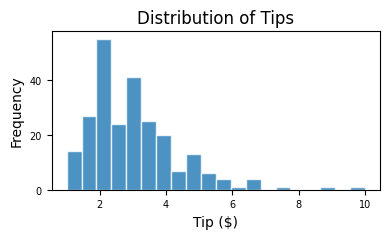

In [ ]:
tips = sns.load_dataset("tips")

# ax = tips["tip"].plot(        ### plot() returns the Axes object, 
                                ### so we can capture it in a variable
tips["tip"].plot(
    kind="hist",
    figsize=(4, 2.5),
    bins=20,
    edgecolor="white",
    alpha=0.8,
    fontsize=7,
    title="Distribution of Tips"
)

plt.xlabel("Tip ($)")
plt.ylabel("Frequency")
plt.tight_layout()

### Scatter Plot

<Axes: title={'center': 'Basic'}, xlabel='total_bill', ylabel='tip'>

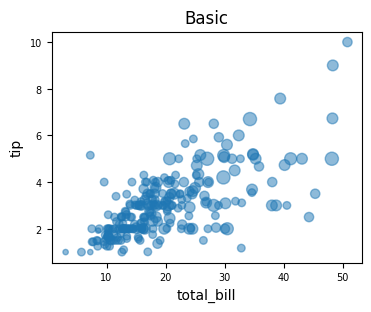

In [ ]:
tips = sns.load_dataset("tips")

tips.plot(
    kind="scatter",
    x="total_bill", y="tip",
    alpha=0.5, fontsize=7,
    title="Basic",
    figsize=(4, 3),
    s=tips["size"] * 15     ### scale size by 'size' column
)

### Bar Plots

Bar plots are one of the most common ways to compare categorical data visually. They represent quantities as rectangular bars whose length (or height) corresponds to the value being measured.

Both bar() and barh() create bar charts — the difference is simply orientation. Stacked bar charts, on the other hand, how multiple subcategories contribute to a total within each main category.  

| Plot Type       | Orientation | Purpose                                  | Best For                                |
| --------------- | ----------- | ---------------------------------------- | --------------------------------------- |
| **Bar Plot**    | Vertical    | Compare category values                  | Simple category comparisons             |
| **Barh Plot**   | Horizontal  | Compare category values with long labels | Readability and ranking-type data       |
| **Stacked Bar** | Either      | Show part-to-whole relationships         | Composition of totals across categories |



#### Vertical Bar Plot

In [ ]:
tips = sns.load_dataset("tips")
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


<Axes: xlabel='day'>

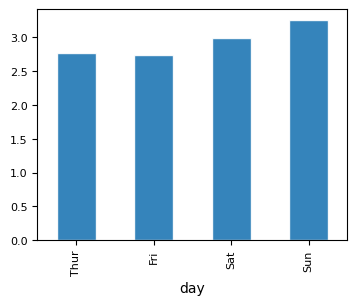

In [ ]:
### bar plot
tips.groupby("day", observed=True)["tip"].mean().plot(kind="bar", 
        figsize=(4, 3), edgecolor="white", alpha=0.9, fontsize=8)

#### Horizontal Bar Plot 

<Axes: ylabel='day'>

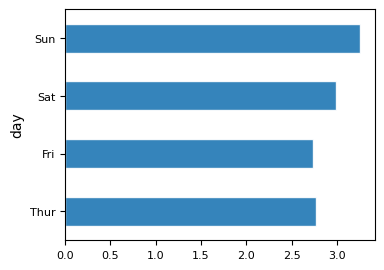

In [ ]:
### bar plot horizontal

tips.groupby("day", observed=True)["tip"].mean().plot(kind="barh", 
        figsize=(4, 3), edgecolor="white", alpha=0.9, fontsize=8)

#### Stacked Bar Plot

<Axes: xlabel='class'>

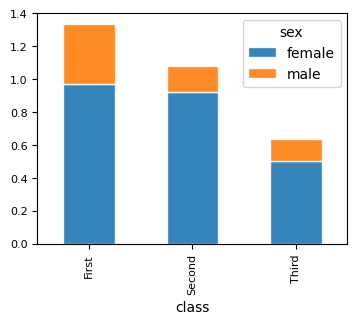

In [ ]:
### titanic — survival count by gender and class
titanic = sns.load_dataset("titanic")

titanic.groupby(["class", "sex"], observed=True)["survived"].mean()\
    .unstack().plot(kind="bar", 
    stacked=True,
    figsize=(4, 3), edgecolor="white", alpha=0.9, fontsize=8)

### BoxPlots

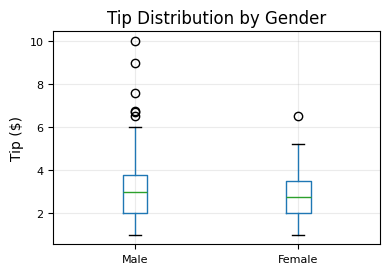

In [ ]:
tips.boxplot(
    column="tip",
    by="sex",
    figsize=(4, 3),
    fontsize=8
)
plt.suptitle("")        # removes default "Boxplot grouped by sex" title
plt.title("Tip Distribution by Gender")
plt.xlabel("")
plt.ylabel("Tip ($)")
plt.grid(alpha=0.25)
plt.tight_layout()

### Area Plot

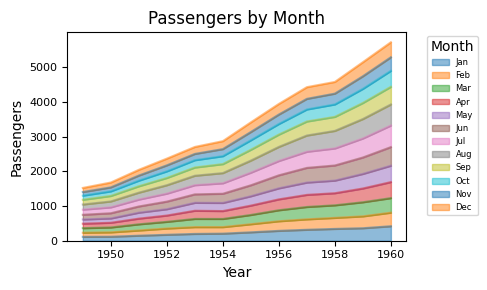

In [ ]:
flights = sns.load_dataset("flights")

df = flights.pivot(index="year", columns="month", values="passengers")

df.plot(
    kind="area",
    figsize=(5, 3),
    alpha=0.5,
    fontsize=8,
    title="Passengers by Month"
)

plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend(title="Month", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=6)
plt.tight_layout()

### KDE Plot

- A Kernel Density Estimate (KDE) plot is smooth version of histogram. 
- Density tells you where values are concentrated. A higher curve means more values are packed in that region. The exact y-value doesn't matter — the shape and peaks are what you read.
  - The peak shows where most values are concentrated
  - A wider curve means more spread in the data
  - The area under the curve always equals 1.0
  - The y-axis shows density — not count or percentage

  species     island  body_mass_g     sex
0  Adelie  Torgersen       3750.0    Male
1  Adelie  Torgersen       3800.0  Female
2  Adelie  Torgersen       3250.0  Female
3  Adelie  Torgersen          NaN     NaN
4  Adelie  Torgersen       3450.0  Female


<Axes: title={'center': 'Penguin Body Mass'}, ylabel='Density'>

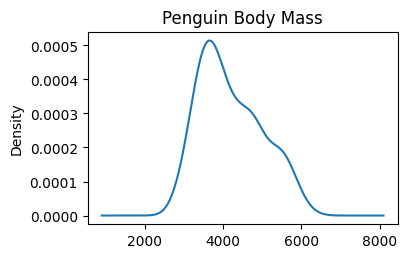

In [ ]:
# %pip install scipy    ### ensure scipy is installed; uncomment when done

# penguins — body mass or flipper length, clear multi-modal distribution
penguins = sns.load_dataset("penguins").drop(columns=\
    ["bill_length_mm", "bill_depth_mm", "flipper_length_mm"])
print(penguins.head())

penguins["body_mass_g"].plot(
    kind="kde", 
    title="Penguin Body Mass",
    figsize=(4,2.5)
    )

We can also overlay KDE with histogram, which makes it clear that a KDE is a smoothed out version of histogram. 

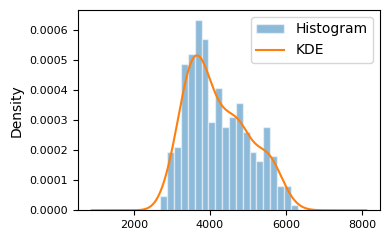

In [ ]:
penguins = sns.load_dataset("penguins").drop(columns=\
    ["bill_length_mm", "bill_depth_mm", "flipper_length_mm"])

penguins["body_mass_g"].plot(
    kind="hist", bins=20,
    edgecolor="white", alpha=0.5,
    density=True,                   ### must be density=True to overlay KDE on histogram
    # title="Histogram",
    fontsize=8, 
    label="Histogram",
    figsize=(4, 2.5)
)

penguins["body_mass_g"].plot(
    kind="kde",
    # title="KDE",
    fontsize=8, 
    label="KDE"
)
plt.legend()
plt.tight_layout()

### Hexagonal Bin Plot

Hexagonal bin plots are useful for bivariate Data and is an alternative to scatterplot.

<Axes: xlabel='a', ylabel='b'>

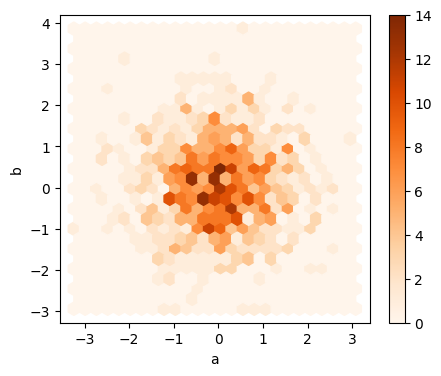

In [ ]:
np.random.seed(42)
df = pd.DataFrame(np.random.randn(1000, 2), columns=['a', 'b'])
df.plot.hexbin(x='a', y='b', 
               gridsize=25, 
               cmap='Oranges',
               figsize=(5, 4),
            )

In [ ]:
### EXERCISE 1: Histogram Fundamentals
# Goal: Visualize the distribution of `A` in `df1`.
# Requirements:
# 1) Plot a histogram for `df1['A']` with exactly 50 bins.
# 2) Set `figsize=(8, 4)` and `alpha=0.7`.
# 3) Add a title: "Distribution of A".
# Stretch: Add vertical dashed lines for the mean and median of `A`.

# Your code here


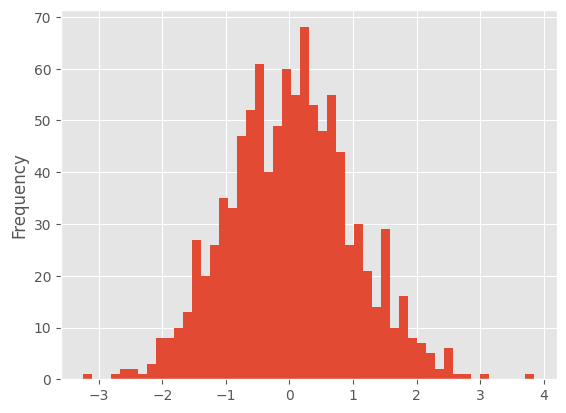

In [ ]:
# Solution
import matplotlib.pyplot as plt
df1['A'].plot.hist(bins=50)
plt.show()

In [ ]:
### EXERCISE 2: Line Plot Styling
# Goal: Show trend behavior for one feature.
# Requirements:
# 1) Plot `df1['B']` as a line plot.
# 2) Use `figsize=(8, 4)` and `lw=2`.
# 3) Set x-label to "Index" and y-label to "B values".
# Stretch: Overlay a rolling mean with window=10 on the same axes.

# Your code here


<Axes: >

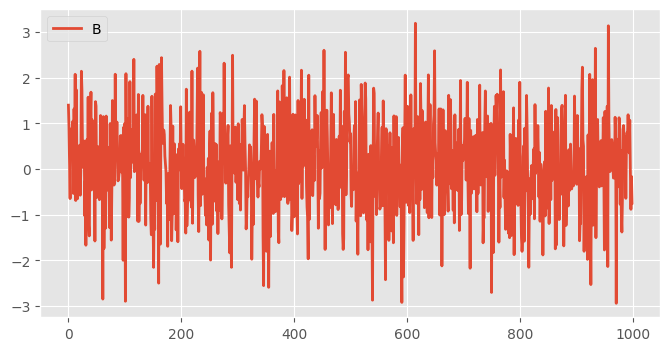

In [ ]:
# Solution
df1.plot.line(y='B', figsize=(8,4), lw=2)

In [ ]:
### EXERCISE 3: Scatter Relationship
# Goal: Examine the relationship between `A` and `B`.
# Requirements:
# 1) Create a scatter plot with `x='A'` and `y='B'`.
# 2) Set `figsize=(7, 5)`.
# 3) Set title to "A vs B".
# Stretch: Add `alpha=0.6` and compare readability.

# Your code here


## Styling

### Plotting Styles

matplotlib offers a range of pre-configured plotting styles. Setting the style can be used to easily give plots the general look that you want. To set the style, the syntax is:

```python
matplotlib.style.use(my_plot_style)
```

To check the aviaible style in the environment, use
```python
plt.style.available
```

Uncomment/comment the following styles one by one to see the style effect.

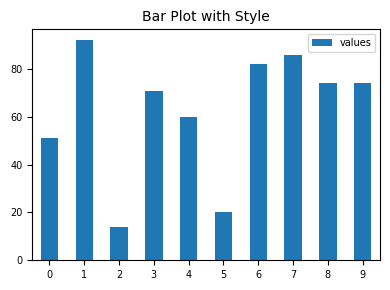

In [20]:
plt.style.use("default")        ### reset to default style
# plt.style.use("ggplot")
# plt.style.use("bmh")  
# plt.style.use("classic") 
# plt.style.use("seaborn-v0_8-muted")  


np.random.seed(42)              ### for reproducibility
df_test = pd.DataFrame({'values': [np.random.randint(0, 100) for num in range(10)]})
df_test.plot.bar(figsize=(4, 3), fontsize=7);
plt.title("Bar Plot with Style", fontsize=10);
plt.legend(fontsize=7, loc="best", bbox_to_anchor=(1, 1));
plt.tick_params(axis='x', rotation=0)
plt.tight_layout()

### Color Maps
- You can use **c** to color based off another column value. 
- Use **cmap** to indicate colormap to use. 
- For all the colormaps, check out: http://matplotlib.org/users/colormaps.html

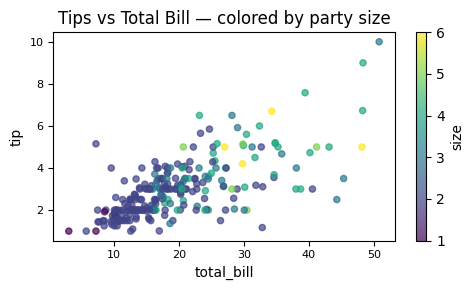

In [ ]:
tips = sns.load_dataset("tips")

ax = tips.plot(
    kind="scatter",
    x="total_bill", y="tip",
    c="size",              # column to map to color
    colormap="viridis",
    figsize=(5, 3),
    alpha=0.7,
    fontsize=8,
    title="Tips vs Total Bill — colored by party size"
)

plt.tight_layout()

Different colormaps can be used for different presentation effects. To see the available colormaps, use the syntax:
```python
plt.colormaps()
```

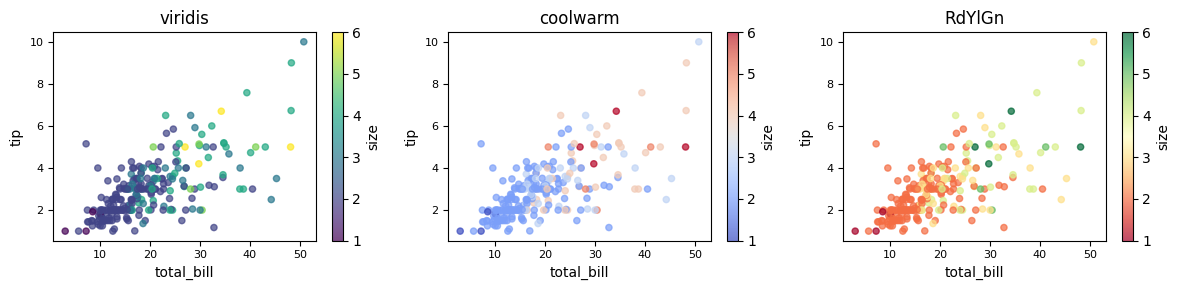

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for ax, cmap in zip(axes, ["viridis", "coolwarm", "RdYlGn"]):
    tips.plot(
        kind="scatter",
        x="total_bill", y="tip",
        c="size",
        colormap=cmap,
        alpha=0.7,
        fontsize=8,
        ax=ax,
        title=cmap
    )

plt.tight_layout()

### Size

Or use s to indicate size based off another column. s parameter needs to be an array, not just the name of a column:

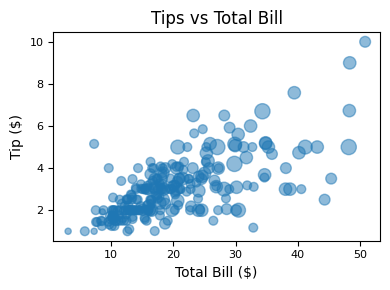

In [ ]:
tips = sns.load_dataset("tips")

ax = tips.plot(
    kind="scatter",
    x="total_bill",
    y="tip",
    s=tips["size"] * 20,
    figsize=(4, 3),
    alpha=0.5,
    fontsize=8,
    title="Tips vs Total Bill"
)

ax.set_xlabel("Total Bill ($)")
ax.set_ylabel("Tip ($)")
plt.tight_layout()

In [ ]:
### EXERCISE 5: Size-Encoded Scatter
# Goal: Add a third variable using marker size.
# Requirements:
# 1) Plot `A` vs `B` from `df1`.
# 2) Use point size based on `abs(C) * 60`.
# 3) Set `alpha=0.5` so overlap stays readable.
# Stretch: Compare size encoding to color encoding and note tradeoffs.

# Your code here


In [ ]:
### EXERCISE 6: Box Plot Comparison
# Goal: Compare spread and outliers across `df2` columns.
# Requirements:
# 1) Create a box plot for all numeric columns in `df2`.
# 2) Use `figsize=(8, 4)`.
# 3) Set title to "Box Plot of df2".
# Stretch: Rotate x tick labels by 30 degrees for readability.

# Your code here


<Axes: >

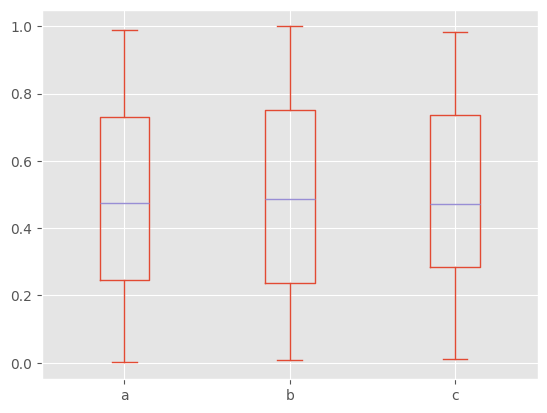

In [ ]:
# Solution
df2.plot.box()

In [ ]:
### EXERCISE 7: Hexbin for Dense Data
# Goal: Visualize dense bivariate data without overplotting.
# Requirements:
# 1) Use the existing `df` with columns `a` and `b`.
# 2) Create a hexbin plot with `gridsize=25`.
# 3) Use a visible colormap (for example, `cmap='Oranges'`).
# Stretch: Change `gridsize` to 15 and 40 and compare detail vs smoothness.

# Your code here


<Axes: xlabel='a', ylabel='b'>

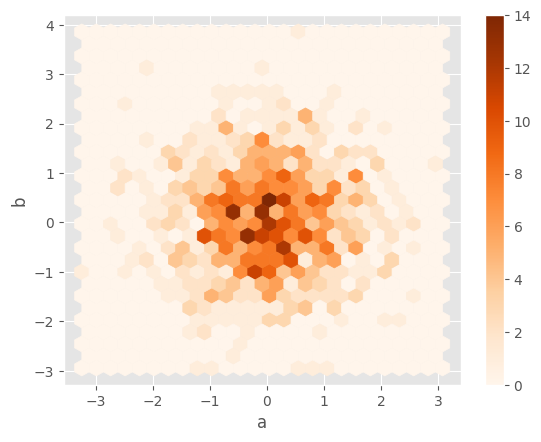

In [ ]:
# Solution
df.plot.hexbin(x='a', y='b', gridsize=25, cmap='Oranges')

In [ ]:
### EXERCISE: KDE for a Single Variable
# Goal: Plot a smooth estimate of one distribution.
# load dataset if needed tips = sns.load_dataset("tips")
# Requirements:
# 1) Plot KDE for `tips['tip']`.
# 2) Set `figsize=(4, 3)`.
# 3) Add title "KDE of Column tip".
### Your code starts here.


### Your code ends here.

<Axes: title={'center': 'KDE of Column tip'}, ylabel='Density'>

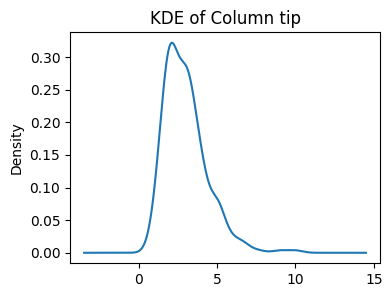

In [ ]:
### Solution

tips['tip'].plot(kind="kde", 
                 figsize=(4,3), 
                 title="KDE of Column tip")

In [ ]:
### EXERCISE:Multi-Column Density Plot
# Goal: Compare distributions of all `df2` columns on one chart.
# Requirements:
# 1) Create a density plot for `df2`.
# 2) Set `figsize=(8, 4)`.
# 3) Add title "Density Curves for df2".
# Stretch: Keep only two columns and compare how interpretation changes.

# Your code here
